[第一章]

## 最小二乘法

高斯于1823年在误差e1 ,… , en独立同分布的假定下,证明了最小二乘方法的一个最优性质: 在所有无偏的线性估计类中,最小二乘方法是其中方差最小的！

### 使用最小二乘法拟和曲线

对于数据$(x_i, y_i)(i=1, 2, 3...,m)$

拟合出函数$h(x)$

有误差，即残差：$r_i=h(x_i)-y_i$

此时L2范数(残差平方和)最小时，h(x) 和 y 相似度最高，更拟合

一般的H(x)为n次的多项式，$H(x)=w_0+w_1x+w_2x^2+...w_nx^n$

$w(w_0,w_1,w_2,...,w_n)$为参数

最小二乘法就是要找到一组 $w(w_0,w_1,w_2,...,w_n)$ 使得$\sum_{i=1}^n(h(x_i)-y_i)^2$ (残差平方和) 最小

即，求 $min\sum_{i=1}^n(h(x_i)-y_i)^2$

----

举例：我们用目标函数$y=sin2{\pi}x$, 加上一个正太分布的噪音干扰，用多项式去拟合【例1.1 11页】

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from LeastSquaresMethod import (
        fit_func,
        fit_polynomial,
        fit_polynomial_regularized,
        real_func,
        residuals_func,
        residuals_func_regularization,
    )
except ModuleNotFoundError as error:
    if error.name != 'LeastSquaresMethod':
        raise
    from least_squares import (
        fit_func,
        fit_polynomial,
        fit_polynomial_regularized,
        real_func,
        residuals_func,
        residuals_func_regularization,
    )
%matplotlib inline

*ps: numpy.poly1d([1,2,3])  生成  $1x^2+2x^1+3x^0$*

In [2]:
# 目标函数、多项式和残差函数由同目录的手写模块提供。
# 这样 notebook 仍展示数学解释，同时核心行为可以被测试。

In [3]:
# 十个点
x = np.linspace(0, 1, 10)
x_points = np.linspace(0, 1, 1000)
# 固定随机数流，使教学图形和输出可复现
rng = np.random.default_rng(0)
# 加上正态分布噪音的目标函数的值
y_ = real_func(x)
y = y_ + rng.normal(0, 0.1, size=x.shape)

def fitting(M=0):
    """
    n 为 多项式的次数
    """    
    # 随机初始化多项式参数
    p_init = rng.random(M+1)
    # 最小二乘法
    p_lsq = fit_polynomial(x, y, degree=M, initial=p_init)
    print('Fitting Parameters:', p_lsq[0])
    
    # 可视化
    plt.plot(x_points, real_func(x_points), label='real')
    plt.plot(x_points, fit_func(p_lsq[0], x_points), label='fitted curve')
    plt.plot(x, y, 'bo', label='noise')
    plt.legend()
    return p_lsq

Fitting Parameters: [0.00846798]


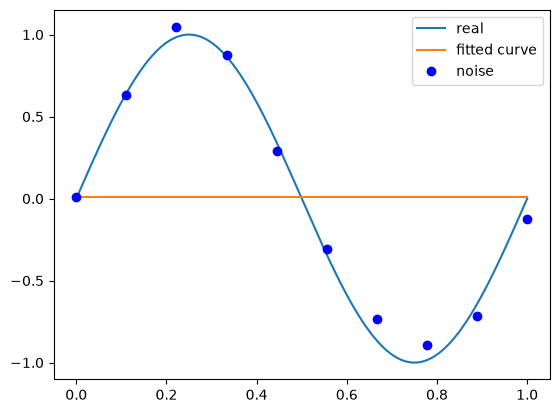

In [4]:
# M=0
p_lsq_0 = fitting(M=0)

Fitting Parameters: [-1.40600122  0.71146859]


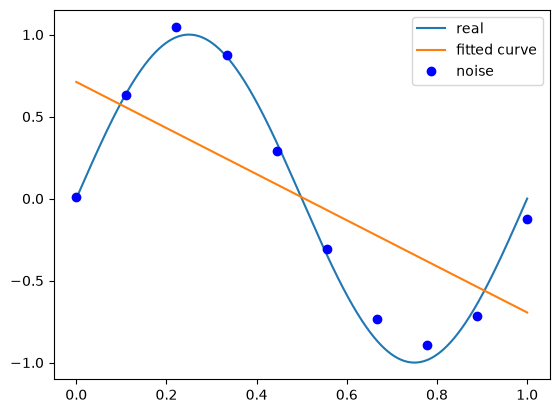

In [5]:
# M=1
p_lsq_1 = fitting(M=1)

Fitting Parameters: [ 1.95316021e+01 -2.97155268e+01  1.01282565e+01 -2.56421600e-02]


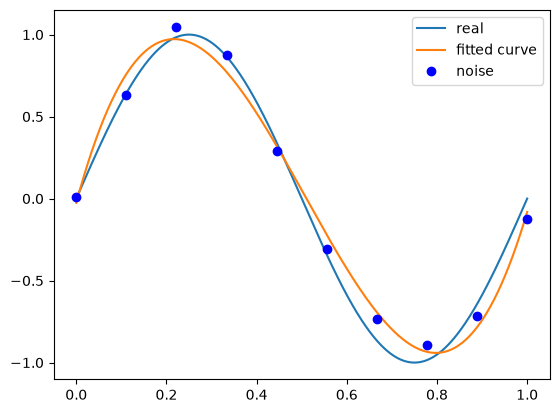

In [6]:
# M=3
p_lsq_3 = fitting(M=3)

Fitting Parameters: [ 2.86083999e+03 -1.31633729e+04  2.53821950e+04 -2.64815102e+04
  1.60286699e+04 -5.55323969e+03  1.01110229e+03 -9.39057843e+01
  9.08225032e+00  1.25730221e-02]


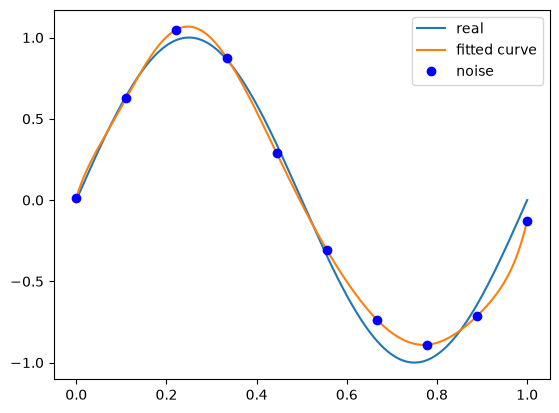

In [7]:
# M=9
p_lsq_9 = fitting(M=9)

当M=9时，多项式曲线通过了每个数据点，但是造成了过拟合

### 正则化

结果显示过拟合， 引入正则化项(regularizer)，降低过拟合

$Q(x)=\sum_{i=1}^n(h(x_i)-y_i)^2+\lambda||w||^2$。

回归问题中，损失函数是平方损失，正则化可以是参数向量的L2范数,也可以是L1范数。

- L1: regularization\*abs(p)

- L2: 0.5 \* regularization \* np.square(p)

In [8]:
regularization = 0.0001  # L2 范数作为正则化项

In [9]:
# 最小二乘法,加正则化项
p_init = rng.random(9+1)
p_lsq_regularization = fit_polynomial_regularized(
    x, y, degree=9, regularization=regularization, initial=p_init
)

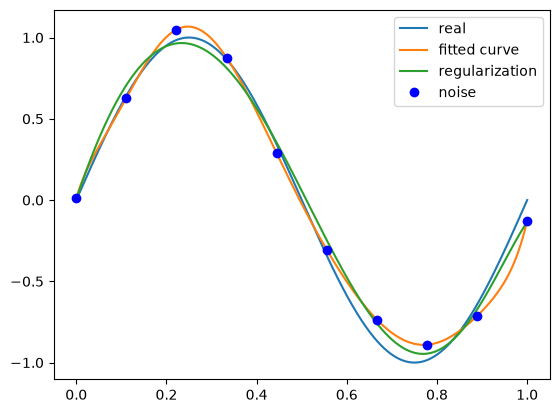

In [10]:
plt.plot(x_points, real_func(x_points), label='real')
plt.plot(x_points, fit_func(p_lsq_9[0], x_points), label='fitted curve')
plt.plot(x_points, fit_func(p_lsq_regularization[0], x_points), label='regularization')
plt.plot(x, y, 'bo', label='noise')
plt.legend()